In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../processed/nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [4]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [6]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [7]:
performance = pd.read_csv("../processed/scheme_performance_clean.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [8]:
cagr_table = performance[[
    "scheme_name",
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct"
]]

cagr_table.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [9]:
cagr_table.to_csv("../reports/cagr_comparison.csv", index=False)

print("CAGR comparison saved successfully!")

CAGR comparison saved successfully!


In [10]:
risk_free_rate = 0.065

sharpe = nav.groupby("amfi_code")["daily_return"].agg(["mean", "std"])

sharpe["sharpe_ratio"] = (
    (sharpe["mean"] * 252 - risk_free_rate)
    / (sharpe["std"] * np.sqrt(252))
)

sharpe.head()

,mean,std,sharpe_ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [11]:
sharpe = sharpe.sort_values("sharpe_ratio", ascending=False)

sharpe.head(10)

,mean,std,sharpe_ratio
amfi_code,,,
148567,0.001074,0.008941,1.448291
120843,0.001082,0.010008,1.306744
148569,0.001124,0.011134,1.234930
119551,0.000917,0.008656,1.208267
120505,0.001161,0.012152,1.180101
149323,0.001055,0.011179,1.132122
100033,0.001080,0.011929,1.093699
118632,0.000865,0.008913,1.081659
101206,0.000852,0.009177,1.027213


In [12]:
sharpe.to_csv("../reports/sharpe_ratio.csv")

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [13]:
import numpy as np

risk_free = 0.065

sortino_list = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    downside = returns[returns < 0]

    if len(downside) > 1:

        downside_std = downside.std()

        sortino = ((returns.mean()*252) - risk_free) / (downside_std*np.sqrt(252))

    else:

        sortino = np.nan

    sortino_list.append([code, sortino])

sortino_df = pd.DataFrame(sortino_list,
                          columns=["amfi_code","Sortino Ratio"])

sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved successfully!")
sortino_df.head()

Sortino Ratio saved successfully!


,amfi_code,Sortino Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [14]:
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

benchmark.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/10_benchmark_indices.csv'

In [15]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [16]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"]

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [17]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()


,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [18]:
merged = pd.merge(
    nav,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [20]:
from scipy.stats import linregress

In [21]:
results = []

for code, group in merged.groupby("amfi_code"):

    group = group.dropna()

    if len(group) < 30:
        continue

    slope, intercept, r, p, std = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    results.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta = pd.DataFrame(results)

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

alpha_beta.head()

Alpha & Beta saved successfully!


,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [22]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (group["nav"] / running_max) - 1

    max_drawdown = drawdown.min()

    drawdown_results.append({
        "amfi_code": code,
        "Max Drawdown": max_drawdown
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.to_csv("../reports/max_drawdown.csv", index=False)

print("Maximum Drawdown saved successfully!")

drawdown_df.head()

Maximum Drawdown saved successfully!


,amfi_code,Max Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [23]:
# Get expense ratio and 3-year return
fund_info = performance[[
    "amfi_code",
    "return_3yr_pct",
    "expense_ratio_pct"
]]

# Merge all results
scorecard = fund_info.merge(sharpe[["sharpe_ratio"]],
                            left_on="amfi_code",
                            right_index=True)

scorecard = scorecard.merge(alpha_beta,
                            on="amfi_code")

scorecard = scorecard.merge(drawdown_df,
                            on="amfi_code")

# Ranking
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["Alpha"].rank(ascending=False)
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()
scorecard["drawdown_rank"] = scorecard["Max Drawdown"].rank(ascending=False)

# Final Score
scorecard["Fund Score"] = (
    scorecard["return_rank"]*0.30 +
    scorecard["sharpe_rank"]*0.25 +
    scorecard["alpha_rank"]*0.20 +
    scorecard["expense_rank"]*0.15 +
    scorecard["drawdown_rank"]*0.10
)

scorecard = scorecard.sort_values("Fund Score")

scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

print("Fund Scorecard saved successfully!")

scorecard.head()

Fund Scorecard saved successfully!


,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,Alpha,Beta,Max Drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,Fund Score
12,120505,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,8.0,5.0,3.0,15.0,25.0,9.00
22,120843,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,11.0,2.0,5.0,22.0,13.0,9.40
7,100033,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,10.0,7.0,6.0,17.0,20.0,10.50
2,119598,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,1.0,14.0,1.0,21.0,36.0,10.75
34,148567,14.81,1.46,1.448291,0.269838,0.023684,-0.112657,17.0,1.0,7.0,23.0,8.0,11.00


In [24]:
top5 = scorecard.nsmallest(5, "Fund Score")["amfi_code"]

top5

12    120505
22    120843
7     100033
2     119598
34    148567
Name: amfi_code, dtype: int64

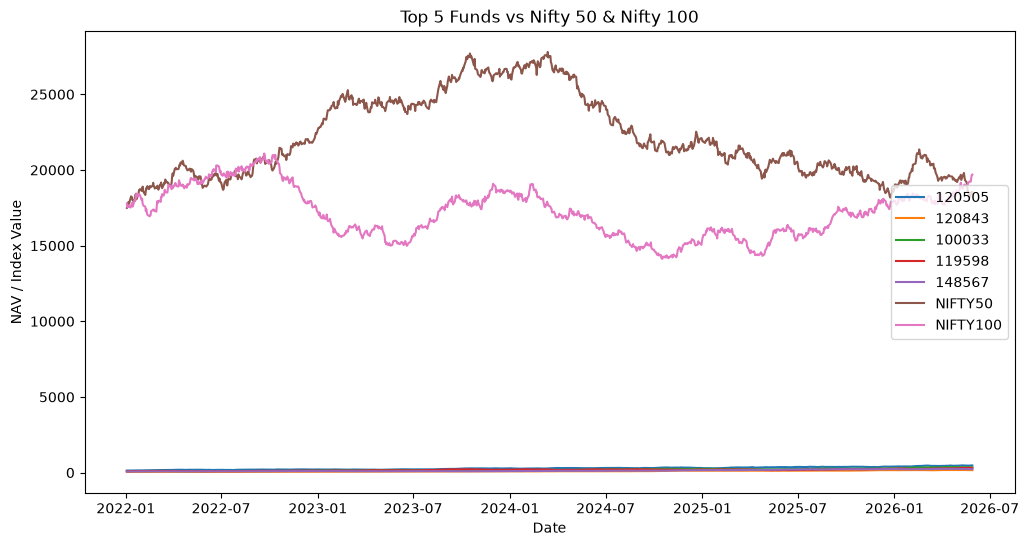

In [25]:
plt.figure(figsize=(12,6))

# Plot Top 5 Funds
for code in top5:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=str(code))

# Plot Benchmarks
for index in ["NIFTY50", "NIFTY100"]:
    temp = benchmark[benchmark["index_name"] == index]
    plt.plot(temp["date"], temp["close_value"], label=index)

plt.title("Top 5 Funds vs Nifty 50 & Nifty 100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")
plt.legend()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

In [26]:
tracking_error = []

for code, group in merged.groupby("amfi_code"):

    group = group.dropna()

    if len(group) < 30:
        continue

    diff = group["daily_return"] - group["benchmark_return"]

    te = diff.std() * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "Tracking Error": te
    })

tracking_df = pd.DataFrame(tracking_error)

tracking_df.head()

,amfi_code,Tracking Error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [27]:
tracking_df.to_csv("../reports/tracking_error.csv", index=False)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!


In [28]:
tracking_df.sort_values("Tracking Error").head(10)

,amfi_code,Tracking Error
5,101208,0.128957
27,120507,0.129044
31,120844,0.129046
1,100025,0.134535
13,118636,0.134758
18,119120,0.135646
12,118635,0.183076
28,120841,0.183119
6,102885,0.183680
15,119093,0.187900
